In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
gas_plants = gpd.read_file("Manufactured_Gas_Plant_Sites.geojson")
counties = gpd.read_file("North_Carolina_State_and_County_Boundary_Polygons.geojson")
watersheds = gpd.read_file("dwq_wsws_20141126_-1629323221143849216.geojson")

Here I wanted to inspect and make sure the data was correctly imported

In [ ]:
gas_plants.head()


In [ ]:
counties.head()

In [ ]:
watersheds.head()

Here I wanted to make sure all the files had the same projections, but since I want to calculate distance, they need to be converted

In [ ]:
watersheds.crs

In [ ]:
watersheds.to_crs(epsg = 2264)

In [ ]:
gas_plants.crs

In [ ]:
gas_plants.to_crs(epsg = 2264)

In [ ]:
counties.crs

In [ ]:
counties.to_crs(epsg= 2264)

Here I want to find how many gas plants are within watersheds

In [ ]:
#1
plants_in_watersheds = gpd.sjoin(gas_plants, watersheds, predicate= "within")
len(plants_in_watersheds)
plants_in_watersheds

In [ ]:
plants_in_watersheds.to_crs(epsg=2264)

In [ ]:
counties.crs

Here I will map this

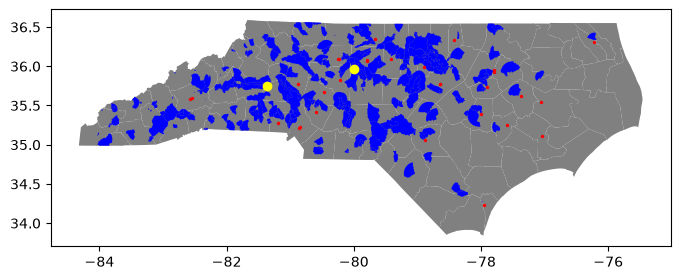

In [158]:
fig, ax = plt.subplots(figsize=(8,7))
counties.plot(ax=ax, color="grey")
watersheds.plot(ax=ax, color="blue")
gas_plants.plot(ax=ax, markersize=2, color="red")
plants_in_watersheds.plot(ax=ax, color="yellow")
plt.show()

I've realized that my gas plant dataset already contains county information, so my counties dataset isn't necessary. I asked ChatGPT what data I could add to make my analysis more robust and fulfill the assignment requirements, and it recommended analyzing water quality assessment information, so I have downloaded bethos sample results to hopefully test whether these gas plants are affecting waterways

In [ ]:
benthos = gpd.read_file("NC_DWR_Benthos_Sample_Results.geojson")

In [ ]:
benthos.head()

In [ ]:
benthos.crs

In [ ]:
benthos.to_crs(epsg=2264)

I used ChatGPT to figure out how to create a new filtered dataset

In [ ]:
bad_benthos = benthos[benthos["Latest_Rating"].isin(["Poor", "Severe"])]

In [ ]:
#2
bad_benthos

In [ ]:
df = gpd.sjoin(bad_benthos, plants_in_watersheds, predicate= "intersects")

I asked ChatGPT why I got an error in the code above "'index_right' cannot be a column name in the frames being joined"

In [ ]:
plants_in_watersheds = plants_in_watersheds.drop(columns="index_right")

In [ ]:
df = gpd.sjoin(bad_benthos, plants_in_watersheds, predicate= "touches")

In [ ]:
df

The means that none of the plants within watersheds were rated poor or severe, which is good! However not substantial for analysis

Let's just do a join of the entire benthos dataframe

In [ ]:
df2 = gpd.sjoin(benthos, plants_in_watersheds, predicate= "intersects")

In [ ]:
df2

This means that there are no assessments that intersect with the watersheds that contain gas plants. Lets look at where the benthos assessments are located and whether a buffer would be necessary

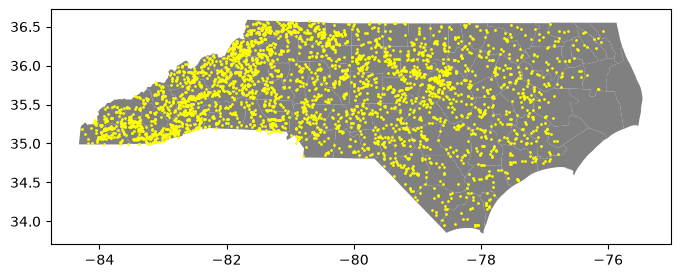

In [160]:
fig, ax = plt.subplots(figsize=(8,7))
counties.plot(ax=ax, color="grey")
benthos.plot(ax=ax, markersize=1, color="yellow")
plt.show()

In [ ]:
#3
bad_watershed = gpd.sjoin(bad_benthos, watersheds, predicate= "intersects")
bad_watershed

In [159]:
#4
CGbad_watershed = bad_watershed[bad_watershed["County"].isin(["Guilford", "Catawba"])]
CGbad_watershed

,Site_ID,View_Details,Water_Body,Location,County,Sampled_Rating,Longitude,Latitude,Latest_Rating,Study_Type,...,index_right,OBJECTID,class,STREAM_NAM,CL_DATE,PCA_TYPE,WSWS_PCA,ClassURL,Area_acers,SecClass
90,BB061,"<a href=""http://www.ncwater.org/?page=672&Site...",HORSEPEN CR,BLEDSOE RD,Guilford,<br />06 Jun 2000 / Poor,-79.892500,36.117500,Poor,Special Study,...,217,218,WS-III NSW,Reedy Fork,8/3/92,P,WS-III NSWP,http://deq.nc.gov/about/divisions/water-resour...,54499.033172,None
97,BB068,"<a href=""http://www.ncwater.org/?page=672&Site...",UT HORSEPEN CR,CROSSTIMBERS DR,Guilford,<br />12 Jul 2001 / Poor,-79.872222,36.123056,Poor,Special Study,...,217,218,WS-III NSW,Reedy Fork,8/3/92,P,WS-III NSWP,http://deq.nc.gov/about/divisions/water-resour...,54499.033172,None
151,CB115,"<a href=""http://www.ncwater.org/?page=672&Site...",HORSEFORD CR,16TH AVE NW,Catawba,<br />12 Sep 2002 / Poor,-81.362222,35.751944,Poor,Special Study,...,316,317,WS-IV,Lake Hickory,8/3/92,P,WS-IVP,http://deq.nc.gov/about/divisions/water-resour...,15332.201671,None
1160,BB114,"<a href=""http://www.ncwater.org/?page=672&Site...",UT E FK DEEP R,I-40,Guilford,<br />28 Sep 1992 / Poor,-79.956944,36.080278,Poor,N/A,...,249,250,WS-IV,East Fork Deep River (High Point Lake),8/3/92,P,WS-IVP,http://deq.nc.gov/about/divisions/water-resour...,16496.064946,None
1168,BB122,"<a href=""http://www.ncwater.org/?page=672&Site...",UT W FK DEEP R,NR W MARKET ST BE LCP,Guilford,<br />13 Oct 1988 / Poor,-80.025556,36.108333,Poor,Special Study,...,250,251,WS-IV,West Fork Deep River,8/3/92,P,WS-IVP,http://deq.nc.gov/about/divisions/water-resour...,14643.128680,None
1199,BB153,"<a href=""http://www.ncwater.org/?page=672&Site...",UT POLECAT CR,SR 3430,Guilford,<br />18 Jul 1990 / Poor,-79.792500,35.978333,Poor,N/A,...,273,274,WS-III,Polecat Creek,8/3/92,P,WS-IIIP,http://deq.nc.gov/about/divisions/water-resour...,33158.316898,None
1610,BB524,"<a href=""http://www.ncwater.org/?page=672&Site...",UT TO HORSEPEN CR,UPS SR 2085 WITHIN RESTORATION,Guilford,<br />07 May 2013 / Poor,-79.878914,36.106725,Poor,Special Study,...,217,218,WS-III NSW,Reedy Fork,8/3/92,P,WS-III NSWP,http://deq.nc.gov/about/divisions/water-resour...,54499.033172,None


Here we see that there in fact are bad benthos assessments within the 2 counties that were identified for having gas plants. Lets see where they are in relation to the gas plants.

In [ ]:
fig, ax = plt.subplots(figsize=(8,7))
counties.plot(ax=ax, color="grey")
CGbad_watershed.plot(ax=ax, color="yellow")
plants_in_watersheds.plot(ax=ax, markersize=1, color="red")
plt.show()

Hmmm, looks like the Catawba gas plant and bad benthos report intersect.

In [ ]:
CGbad_watershed = CGbad_watershed.drop(columns="index_right")
catawba_site = gpd.sjoin(plants_in_watersheds, CGbad_watershed, predicate="intersects")

In [ ]:
catawba_site

In [ ]:
plants_in_watersheds

Here I insert data that contains information about violations of water supplies and populations served

In [ ]:
water_report = pd.read_csv("Water System Summary_20261008.csv")

In [ ]:
water_report

In [ ]:
CGbad_drinking = CGbad_watershed.merge(water_report, left_on ="County", right_on= "Counties Served", how="left")
CGbad_drinking

Now we have all of the badly rated watersheds with their population served and number of violations. Lets join all the benthos reports with their population and violation information

In [ ]:
quality_report = benthos.merge(water_report, left_on="County", right_on= "Counties Served", how="left")

Now lets join that with the watershed data

In [ ]:
comprehensive = gpd.sjoin(watersheds, quality_report, predicate= "intersects")
comprehensive

In [ ]:
comprehensive = comprehensive.drop(columns="index_right")


In [ ]:
watershedsgasplants_comprehensive = gpd.sjoin(gas_plants, comprehensive, predicate="within")

In [ ]:
watershedsgasplants_comprehensive

Now I have created multiple layers, a "comprehensive" layer that contains watershed data with their benthos assessment and drinking water report. I created a layer that defines what gas plants are within watersheds. I have